## Практическое домашнее задание. Группа Advanced (до 18 апреля, 23.59)

### Цель
Реализовать систему рекомендаций с использованием кластеризации на выбранном датасете и проверить качество через автоматические тесты.

### Задание

**Часть 1: Выбор и подготовка данных**
1. Выберите любой релевантный датасет:
   - MovieLens (фильмы)
   - Amazon Reviews (товары)
   - Last.fm (музыка)
   - Online Retail (товары)
   - Любой другой с числовыми признаками для кластеризации
2. Выберите минимум **4 числовых признака** для кластеризации
3. Проведите предобработку: очистка от пропусков, масштабирование

**Часть 2: Кластеризация**
1. Обучите модель KMeans с подбором количества кластеров
2. Обоснуйте выбор количества кластеров (графики Elbow и Silhouette)
3. Вычислите метрики качества: Silhouette Score, Davies-Bouldin Index

**Часть 3: Функция рекомендаций**
1. Реализуйте функцию `recommend(item_id, n_recommendations)`, которая возвращает топ-N похожих объектов из того же кластера
2. Функция должна исключать исходный объект из рекомендаций

**Часть 4: Тестирование**
Напишите тесты для проверки:
1. **Исполняемость кода** — все функции запускаются без ошибок
2. **Метрики качества** — Silhouette Score > 0.2, Davies-Bouldin < 1.5
3. **Корректность рекомендаций** — рекомендуемые объекты принадлежат тому же кластеру, исходный объект исключен

### Критерии оценки

| Критерий | Вес |
|----------|-----|
| Код исполняется без ошибок | 20% |
| Обоснованный выбор количества кластеров (графики + анализ) | 20% |
| Silhouette Score > 0.2 | 20% |
| Davies-Bouldin Index < 1.5 | 20% |
| Функция рекомендаций корректна + тесты проходят | 20% |

### Формат сдачи
- Jupyter Notebook с комментариями
- Отдельный файл с тестами (`test_clustering.py`)
- README с описанием датасета и результатами

## Импорты

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

## Загрузка и обработка данных

Используем [датасет фильмов с рейтингом IMDB](https://github.com/shishir349/Analyzing-the-IMDB-Movie-Dataset/blob/master/movie_metadata.csv). Он содержит данные о 5043 фильмах 1916-2016 гг. выпуска (название фильма, режиссер, продолжительность, год выхода, жанры, рейтинг, бюджет, сборы, информация об актерах, количество лайков на Facebook и др.)

In [116]:
!wget https://raw.githubusercontent.com/shishir349/Analyzing-the-IMDB-Movie-Dataset/master/movie_metadata.csv -O movie_metadata.csv

--2026-04-18 17:48:57--  https://raw.githubusercontent.com/shishir349/Analyzing-the-IMDB-Movie-Dataset/master/movie_metadata.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1494688 (1.4M) [text/plain]
Saving to: ‘movie_metadata.csv’

movie_metadata.csv  100%[===================>]   1.42M  --.-KB/s    in 0.06s   

2026-04-18 17:48:57 (25.0 MB/s) - ‘movie_metadata.csv’ saved [1494688/1494688]



In [142]:
# Загрузка данных
df_raw = pd.read_csv('movie_metadata.csv')
print(f'Загружен датасет размерности: {df_raw.shape}')
display(df_raw.head())

# Удалим 1-й квартиль фильмов с наименьшим количеством оценок (для наглядности)
voted_quantile = df_raw['num_voted_users'].quantile(0.25)
df = df_raw[df_raw['num_voted_users'] > voted_quantile]
print(f'Удалено {len(df_raw)-len(df)} фильмов с менее {voted_quantile.round()} оценок\n')

# Отбор признаков
df.sort_index(axis=1).info()
df = df[['movie_title', 'genres', 'language', 'title_year', 'duration', 'imdb_score']]

# Из исходных числовых признаков для кластеризации выберем длительность и рейтинг IMDB
feature_cols = ['duration', 'imdb_score']

# Преобразуем данные о жанрах через one-hot кодирование и добавим их к признакам
df_genres = df['genres'].str.get_dummies(sep='|')
# Удаляем малочисленные жанры (близкое к нулю std)
df_genres = df_genres.loc[:, df_genres.sum() > len(df_genres) * 0.01]
genre_cols = df_genres.columns.to_list()
feature_cols.extend(genre_cols)
full_df = pd.concat([df, df_genres], axis=1)

# Также добавим бинарный признак на основе языка (англ/не англ)
full_df['is_english'] = (df['language'] == 'English').astype(int)
feature_cols.append('is_english')

print('\nПризнаки для кластеризации:')
print(*[str(i+1)+". "+str(f) for i, f in enumerate(full_df[feature_cols].columns.to_list())],sep='\n')

# Очистка от пропусков
full_df = full_df.dropna()

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(full_df[feature_cols])
print(f'\nРазмерность матрицы признаков: {X_scaled.shape}')

Загружен датасет размерности: (5043, 28)


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


Удалено 1261 фильмов с менее 8594.0 оценок

<class 'pandas.core.frame.DataFrame'>
Index: 3782 entries, 0 to 5039
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   actor_1_facebook_likes     3782 non-null   float64
 1   actor_1_name               3782 non-null   object 
 2   actor_2_facebook_likes     3780 non-null   float64
 3   actor_2_name               3780 non-null   object 
 4   actor_3_facebook_likes     3776 non-null   float64
 5   actor_3_name               3776 non-null   object 
 6   aspect_ratio               3758 non-null   float64
 7   budget                     3565 non-null   float64
 8   cast_total_facebook_likes  3782 non-null   int64  
 9   color                      3778 non-null   object 
 10  content_rating             3750 non-null   object 
 11  country                    3781 non-null   object 
 12  director_facebook_likes    3724 non-null   float64
 13  director_

## Кластеризация

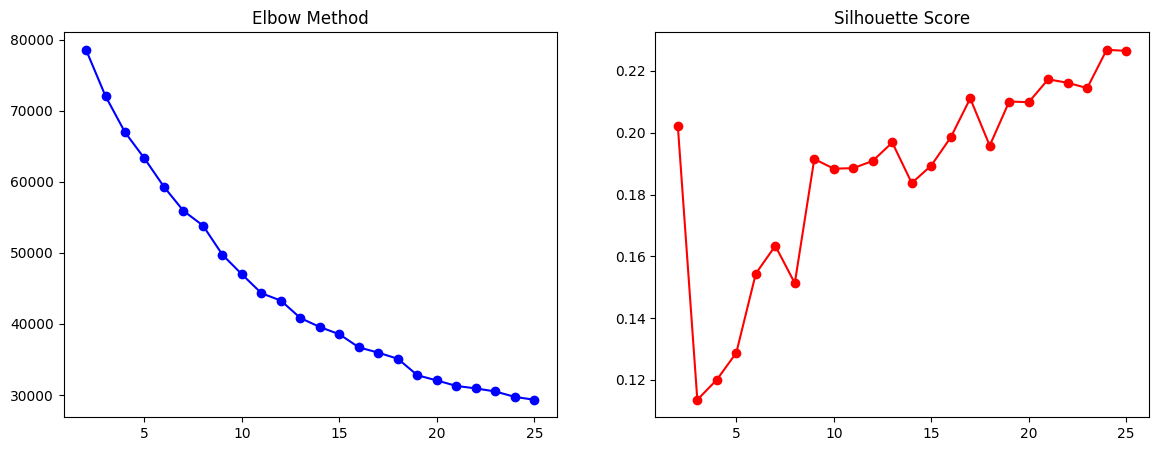

In [118]:
# Подбор оптимального количества кластеров
inertias = []
silhouette_scores = []
K_range = range(2, 26)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация для выбора k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_title('Silhouette Score')
plt.show()

Основываясь на методе локтя, оптимальное значение k может быть равно 13, 16 или 19. Однако по Silhoette score наибольшие значения достигаются при k=24, k=25, k=21. В матрице признаков 20 жанров, поэтому распределение на ~20 кластеров может быть оправдано, однако чем больше значение k, тем выше вероятность переобучения. Выберем k=17 в качестве оптимального, так как при нем значениe Silhouette score больше, чем для соседних k, и превышает 0.2.

In [147]:
# Обучение финальной модели
optimal_k = 17  # выбирается по графикам
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
full_df['cluster'] = kmeans.fit_predict(X_scaled)
cluster_sizes = full_df['cluster'].value_counts()
print(f"Silhoette Score (k={optimal_k}): {silhouette_score(X_scaled, kmeans.labels_):.4f}")
print(f"Davies-Bouldin Score (k={optimal_k}): {davies_bouldin_score(X_scaled, kmeans.labels_):.4f}")
print(f"Минимальный размер кластера: {cluster_sizes.min()}")
print(f"Максимальный размер кластера: {cluster_sizes.max()}")

Silhoette Score (k=17): 0.2111
Davies-Bouldin Score (k=17): 1.3952
Минимальный размер кластера: 32
Максимальный размер кластера: 629


## Функция рекомендаций

In [120]:
def recommend_by_cluster(movie_id, df, n_recommendations=5):
    cluster = df.loc[movie_id, 'cluster']
    cluster_tracks = df[df['cluster'] == cluster]
    return cluster_tracks.drop(movie_id).head(n_recommendations)

In [154]:
example = full_df.sample()
display(example)
recommend_by_cluster(df=full_df, movie_id=example.index[0])

,movie_title,genres,language,title_year,duration,imdb_score,Action,Adventure,Animation,Biography,...,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,is_english,cluster
2457,Anything Else,Comedy|Romance,English,2003.0,108.0,6.4,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


,movie_title,genres,language,title_year,duration,imdb_score,Action,Adventure,Animation,Biography,...,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,is_english,cluster
26,Titanic,Drama|Romance,English,1997.0,194.0,7.7,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
50,The Great Gatsby,Drama|Romance,English,2013.0,143.0,7.3,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
101,The Curious Case of Benjamin Button,Drama|Fantasy|Romance,English,2008.0,166.0,7.8,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
233,How Do You Know,Comedy|Drama|Romance,English,2010.0,121.0,5.3,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
234,Knight and Day,Action|Comedy|Romance,English,2010.0,117.0,6.3,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


По примеру заметно, что в один кластер попали фильмы примерно одного жанра (romance, drama, comedy). Рассмотрим распределение значений жанровых признаков по кластерам:

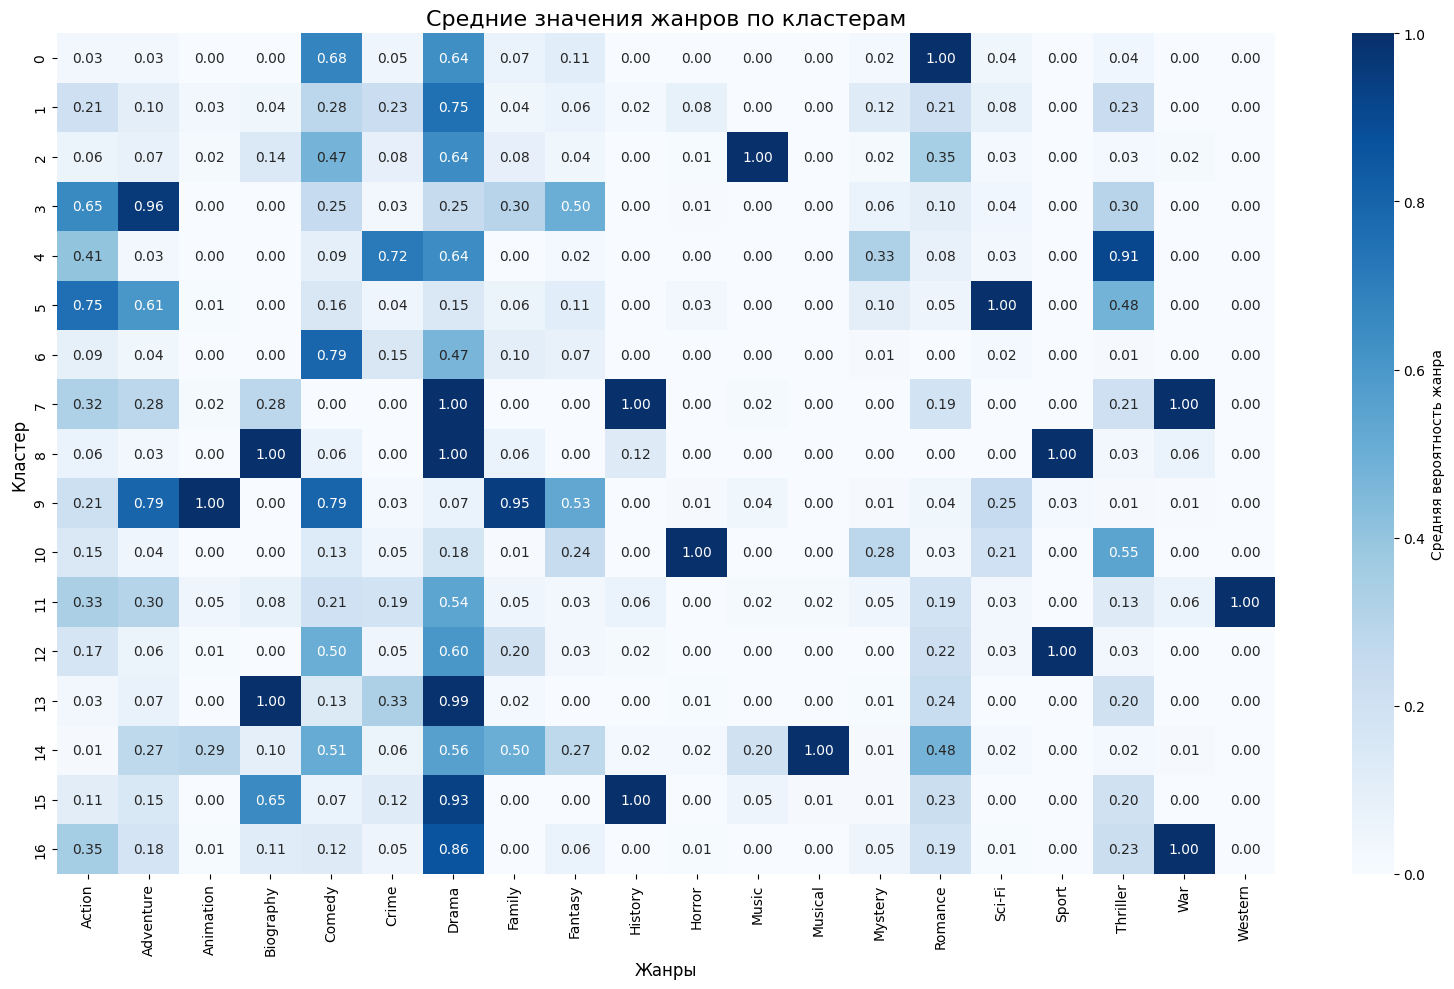

In [122]:
# Визуализация средних значений жанров по кластерам в виде тепловой карты
cluster_profiles = full_df.groupby('cluster')[genre_cols].mean()

plt.figure(figsize=(16, 10))
sns.heatmap(cluster_profiles,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            cbar_kws={'label': 'Средняя вероятность жанра'})
plt.title('Средние значения жанров по кластерам', fontsize=16)
plt.xlabel('Жанры', fontsize=12)
plt.ylabel('Кластер', fontsize=12)
plt.tight_layout()
plt.show()

На тепловой карте можно заметить, что более 75% фильмов каждого кластера относятся к одному или 2-4 определенным жанрам. Это свидетельствует о высоком уровне интерпретируемости полученных кластеров. Некоторые жанры образуют группы, так как часто совстречаются, например, History & War & Drama, Biography & Drama & Sport, Animation & Family & Adventure & Comedy.

## Сохранение датасета и полученных кластеров

In [123]:
full_df.drop('cluster', axis=1).to_csv('movie_rec.csv')
full_df['cluster'].to_csv('clusters.csv')